# 03 — Module B: Time Series Forecasting
## Universal Sequence Lab · Assignment 3

**Task:** Multi-step temperature forecasting using the **Jena Climate** dataset.

Given 96 hours of weather measurements → predict the next **24 hours** of temperature.

**Models compared:**
1. Naive Baseline (last-value persistence)
2. LSTM Forecaster
3. GRU Forecaster
4. Transformer Forecaster

**Metrics:** MAE, RMSE, MAPE

---

In [6]:
!pip install scikit-learn seaborn -q

import sys
sys.path.append('/content/src')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from models import LSTMForecaster, GRUForecaster, TransformerForecaster
from dataset import get_weather_loaders
from train import train_model, plot_learning_curves, plot_forecast, count_parameters, evaluate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cuda


## 1. Load Data


In [7]:
SEQ_LEN    = 96    # 4 days of hourly data
HORIZON    = 24   # predict next 24 hours
BATCH_SIZE = 64
N_FEATURES = 5    # T, p, rh, wv, Tdew

train_loader, val_loader, test_loader, scaler, features = get_weather_loaders(
    batch_size=BATCH_SIZE, seq_len=SEQ_LEN, horizon=HORIZON)

# Verify shapes
x_batch, y_batch = next(iter(train_loader))
print(f'X shape: {x_batch.shape}  →  (batch, seq_len, features)')
print(f'y shape: {y_batch.shape}  →  (batch, horizon)')

  Features: ['T (degC)', 'p (mbar)', 'rh (%)', 'wv (m/s)', 'Tdew (degC)']
  Train: 48945 | Val: 6890 | Test: 13900
X shape: torch.Size([64, 96, 5])  →  (batch, seq_len, features)
y shape: torch.Size([64, 24])  →  (batch, horizon)


## 2. Initialize Models


In [8]:
HIDDEN_DIM = 128
N_LAYERS   = 2
DROPOUT    = 0.2
D_MODEL    = 64
N_HEADS    = 4
FF_DIM     = 256
T_LAYERS   = 2
N_EPOCHS   = 20
LR         = 1e-3

models_config = {
    'LSTM':        LSTMForecaster(N_FEATURES, HIDDEN_DIM, HORIZON, N_LAYERS, DROPOUT),
    'GRU':         GRUForecaster(N_FEATURES, HIDDEN_DIM, HORIZON, N_LAYERS, DROPOUT),
    'Transformer': TransformerForecaster(N_FEATURES, D_MODEL, N_HEADS, FF_DIM,
                                         HORIZON, T_LAYERS, DROPOUT),
}

print('Parameter counts:')
for name, model in models_config.items():
    print(f'\n  {name}:')
    count_parameters(model)

Parameter counts:

  LSTM:
  Total params:     204,312
  Trainable params: 204,312

  GRU:
  Total params:     154,008
  Trainable params: 154,008

  Transformer:
  Total params:     101,912
  Trainable params: 101,912


## 3. Naive Baseline (Persistence Model)


In [9]:
# Naive: predict last temperature value repeated across the horizon
all_preds, all_true = [], []
for x, y in test_loader:
    naive_pred = x[:, -1, 0:1].repeat(1, HORIZON)  # last observed temp
    all_preds.append(naive_pred.numpy())
    all_true.append(y.numpy())

naive_pred = np.vstack(all_preds)
naive_true = np.vstack(all_true)

naive_rmse = np.sqrt(np.mean((naive_pred - naive_true)**2))
naive_mae  = np.mean(np.abs(naive_pred - naive_true))
print(f'Naive Baseline → RMSE: {naive_rmse:.4f} | MAE: {naive_mae:.4f}')

Naive Baseline → RMSE: 0.5219 | MAE: 0.3871


In [10]:
import os
os.makedirs('/content/models', exist_ok=True)

## 4. Train All Models


In [11]:
histories = {}
criterion = nn.MSELoss()

for name, model in models_config.items():
    print(f'\n{'='*50}')
    print(f' Training: {name}')
    print(f'{'='*50}')
    model = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS)

    hist = train_model(
        model, train_loader, val_loader, optimizer, criterion, DEVICE,
        n_epochs=N_EPOCHS, task='forecasting',
        scheduler=scheduler, model_name=name,
        save_path=f'/content/models/ts_{name}.pt'
    )
    histories[name] = hist
    models_config[name] = model


 Training: LSTM


/content/train.py:117: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_loss)


[LSTM] Epoch 01/20 | Train Loss: 0.1382 | Val Loss: 0.0882 | Val RMSE: 0.2973 | 4.8s
[LSTM] Epoch 02/20 | Train Loss: 0.0945 | Val Loss: 0.0867 | Val RMSE: 0.2947 | 4.9s
[LSTM] Epoch 03/20 | Train Loss: 0.0885 | Val Loss: 0.0784 | Val RMSE: 0.2803 | 4.8s
[LSTM] Epoch 04/20 | Train Loss: 0.0847 | Val Loss: 0.0840 | Val RMSE: 0.2900 | 4.8s
[LSTM] Epoch 05/20 | Train Loss: 0.0813 | Val Loss: 0.0782 | Val RMSE: 0.2798 | 5.0s
[LSTM] Epoch 06/20 | Train Loss: 0.0771 | Val Loss: 0.0845 | Val RMSE: 0.2911 | 4.9s
[LSTM] Epoch 07/20 | Train Loss: 0.0732 | Val Loss: 0.0820 | Val RMSE: 0.2866 | 5.0s
[LSTM] Epoch 08/20 | Train Loss: 0.0690 | Val Loss: 0.0870 | Val RMSE: 0.2953 | 4.9s
[LSTM] Epoch 09/20 | Train Loss: 0.0640 | Val Loss: 0.0871 | Val RMSE: 0.2952 | 5.0s
[LSTM] Epoch 10/20 | Train Loss: 0.0592 | Val Loss: 0.0910 | Val RMSE: 0.3019 | 5.1s
[LSTM] Epoch 11/20 | Train Loss: 0.0531 | Val Loss: 0.0952 | Val RMSE: 0.3089 | 5.0s
[LSTM] Epoch 12/20 | Train Loss: 0.0475 | Val Loss: 0.0992 | Val 

## 5. Learning Curves


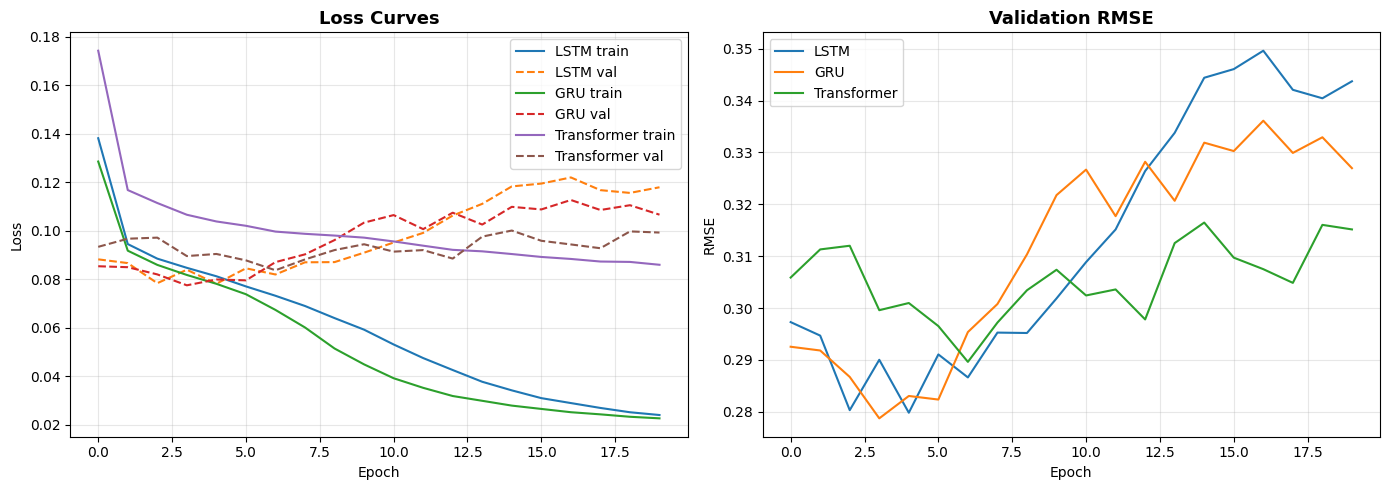

In [12]:
fig = plot_learning_curves(histories, task='forecasting')

## 6. Test Evaluation & Forecast Visualization


In [13]:
results = {}
criterion_eval = nn.MSELoss()

for name, model in models_config.items():
    model.load_state_dict(torch.load(f'/content/models/ts_{name}.pt', map_location=DEVICE))
    test_loss, preds, labels = evaluate(model, test_loader, criterion_eval,
                                         DEVICE, task='forecasting')
    rmse = np.sqrt(np.mean((preds - labels)**2))
    mae  = np.mean(np.abs(preds - labels))
    results[name] = {'rmse': rmse, 'mae': mae, 'preds': preds, 'labels': labels}
    print(f'{name:15s} | RMSE: {rmse:.4f} | MAE: {mae:.4f}')

print(f'\nNaive baseline | RMSE: {naive_rmse:.4f} | MAE: {naive_mae:.4f}')

LSTM            | RMSE: 0.2881 | MAE: 0.2184
GRU             | RMSE: 0.2884 | MAE: 0.2176
Transformer     | RMSE: 0.3257 | MAE: 0.2335

Naive baseline | RMSE: 0.5219 | MAE: 0.3871


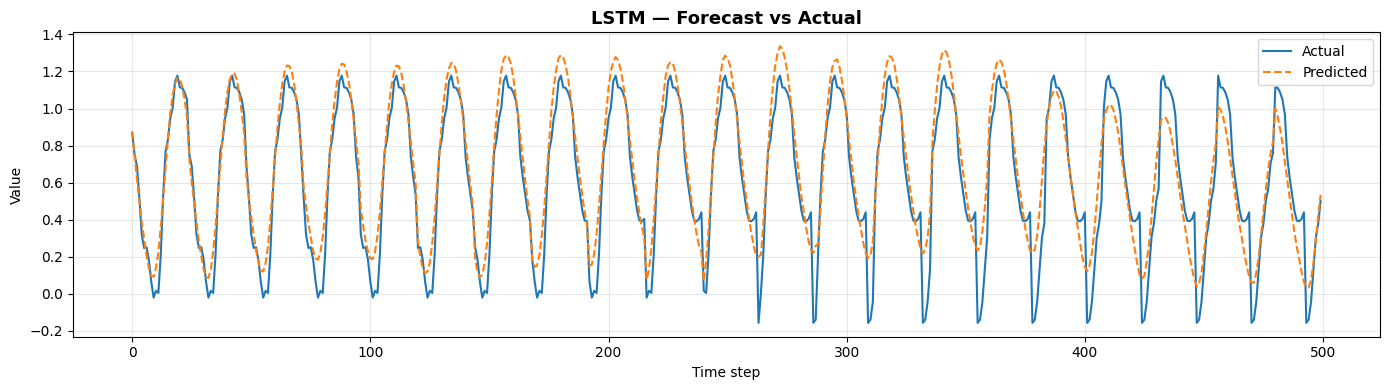

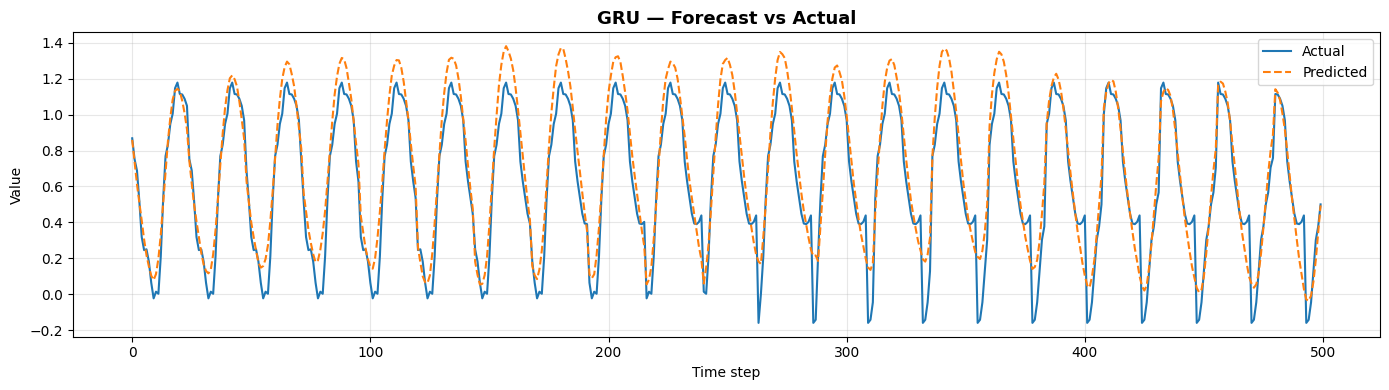

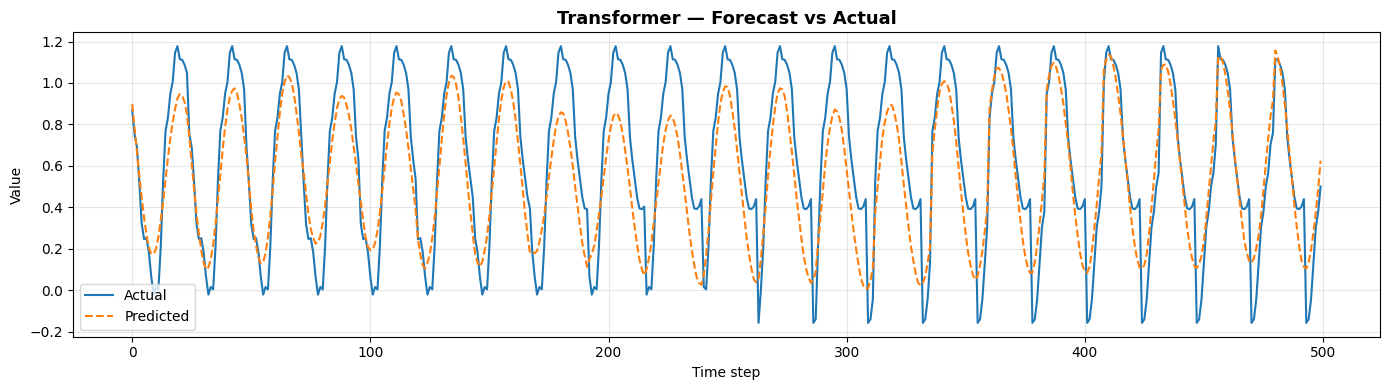

In [14]:
# Plot forecasts vs actual for each model
for name, res in results.items():
    # Flatten multi-step predictions for visualization
    flat_pred = res['preds'].flatten()
    flat_true = res['labels'].flatten()
    plot_forecast(flat_true, flat_pred, title=f'{name} — Forecast vs Actual', n_samples=500)

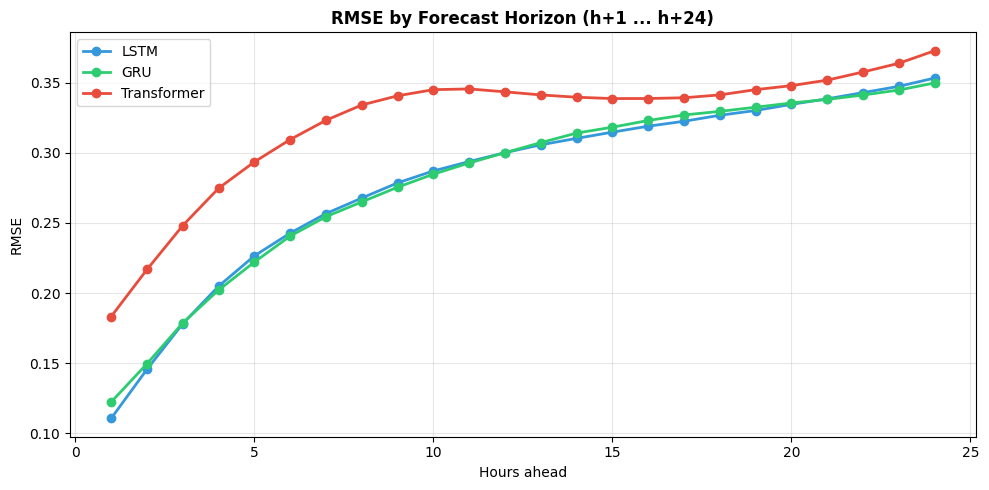

In [15]:
# ── Per-horizon RMSE: how accuracy degrades with forecast horizon ─────
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']

for (name, res), color in zip(results.items(), colors):
    preds  = res['preds'].reshape(-1, HORIZON)   # (n_samples, horizon)
    labels = res['labels'].reshape(-1, HORIZON)
    per_horizon_rmse = [np.sqrt(np.mean((preds[:, h] - labels[:, h])**2))
                        for h in range(HORIZON)]
    ax.plot(range(1, HORIZON+1), per_horizon_rmse, marker='o',
            label=name, color=color, linewidth=2)

ax.set_title('RMSE by Forecast Horizon (h+1 ... h+24)', fontweight='bold')
ax.set_xlabel('Hours ahead')
ax.set_ylabel('RMSE')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_horizon.png', bbox_inches='tight')
plt.show()